In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("dark_background")

In [53]:
def f(x):
    return 1 + np.sin(x)
# end

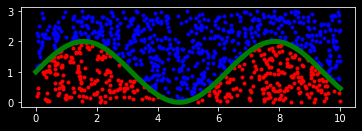

In [85]:
n_points = 1000

xmin = 0
xmax = 10

ymax = 3

x = np.random.uniform(xmin,xmax,n_points)
y = np.random.uniform(   0,ymax,n_points)

for i in range(n_points):
    if f(x[i]) > y[i]:
        plt.plot( x[i], y[i], 'r.' )
    else:
        plt.plot( x[i], y[i], 'b.' )
    # end
# end

plotX = np.linspace(xmin,xmax,100)
plotY = f(plotX)
plt.plot(plotX,plotY,'g',linewidth=5)

plt.gca().set_aspect("equal")

In [86]:
def CalcIntegral(n_points, xmin, xmax, ymax, f):
    x = np.random.uniform(xmin,xmax,n_points)
    y = np.random.uniform(   0,ymax,n_points)
    
    n_points_under_curve = 0.0
    for i in range(n_points):
        if f(x[i]) > y[i]:
            n_points_under_curve+=1
        # end
    # end
    
    return ymax*(xmax-xmin) * n_points_under_curve / n_points
# end

In [87]:
CalcIntegral(10000, xmin, xmax, ymax, f)

11.583

In [88]:
n_points_array = 2**np.arange(4,16,2)
print(n_points_array)
print()

n_repeat = 100

areas = []
for i in range(n_repeat):
    areas.append([])
    for j in n_points_array:
        areas[i].append( CalcIntegral(j, xmin, xmax, ymax, f) )
    # ene
# end
areas = np.array(areas)

df = pd.DataFrame(areas, columns=n_points_array)
df

[   16    64   256  1024  4096 16384]



,16,64,256,1024,4096,16384
0,9.375,8.43750,11.718750,11.748047,11.696777,11.713257
1,7.500,10.31250,12.070312,11.806641,11.447754,11.707764
2,18.750,14.06250,12.890625,12.128906,11.791992,11.788330
3,15.000,13.12500,11.835938,11.894531,11.887207,11.733398
4,11.250,15.00000,12.539062,12.187500,11.916504,11.830444
...,...,...,...,...,...,...
95,15.000,14.06250,11.601562,11.337891,11.748047,11.856079
96,15.000,10.78125,11.250000,12.626953,11.682129,11.850586
97,13.125,10.78125,11.718750,12.392578,11.909180,11.700439
98,7.500,10.31250,10.429688,11.572266,11.608887,11.852417


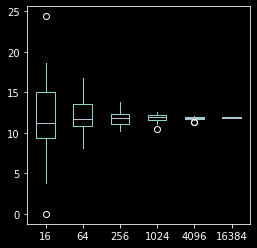

In [89]:
fig = plt.figure(figsize=(4,4))
df.boxplot()

plt.grid(False)